In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

pl.Config.set_tbl_rows(8)
plt.style.use('seaborn-v0_8-darkgrid')

DATA_DIR       = "../data"
INPUT_PARQUET  = f"{DATA_DIR}/interim/metrics_featured.parquet"
MODEL_DIR      = "../outputs/models"
REPORT_DIR     = "../outputs/reports"

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

df = pl.read_parquet(INPUT_PARQUET)

print("=" * 60)
print("  NOTEBOOK 03 — 5-Model ML Baseline Comparison")
print("=" * 60)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Machines: {df['machine'].n_unique()}")

  NOTEBOOK 03 — 5-Model ML Baseline Comparison
  Rows    : 83,244
  Columns : 40
  Machines: 100


In [2]:
# We forecast 3 targets at 3 horizons each = 9 future columns
# 5-min → 1 step | 15-min → 3 steps | 30-min → 6 steps

HORIZONS = {"5min": 1, "15min": 3, "30min": 6}
TARGET_COLS = ["target_gpu_pct", "target_cpu_pct", "target_load"]

future_exprs = []
for col in TARGET_COLS:
    for label, steps in HORIZONS.items():
        future_exprs.append(
            pl.col(col).shift(-steps).over("machine")
            .alias(f"FUTURE_{col}_{label}")
        )

df_model = df.with_columns(future_exprs).drop_nulls()

print(f"✅ Future targets created: {len(future_exprs)} columns")
print(f"   Targets   : {TARGET_COLS}")
print(f"   Horizons  : {list(HORIZONS.keys())}")
print(f"   Rows after drop_nulls: {df_model.shape[0]:,}")

✅ Future targets created: 9 columns
   Targets   : ['target_gpu_pct', 'target_cpu_pct', 'target_load']
   Horizons  : ['5min', '15min', '30min']
   Rows after drop_nulls: 82,644


In [3]:
# Chronological split — NEVER shuffle time series data
g_min = df_model["timestamp"].min()
g_max = df_model["timestamp"].max()
dur   = g_max - g_min

train_cut = g_min + dur * 0.70
val_cut   = g_min + dur * 0.85

train_df = df_model.filter(pl.col("timestamp") <= train_cut).to_pandas()
val_df   = df_model.filter((pl.col("timestamp") > train_cut) & (pl.col("timestamp") <= val_cut)).to_pandas()
test_df  = df_model.filter(pl.col("timestamp") > val_cut).to_pandas()

print(f"✅ Chronological split complete")
print(f"   Train : {train_df.shape[0]:,} rows  (70%)")
print(f"   Val   : {val_df.shape[0]:,} rows  (15%)")
print(f"   Test  : {test_df.shape[0]:,} rows  (15%)")
print(f"\n   Train period: {train_df['timestamp'].min()} → {train_df['timestamp'].max()}")
print(f"   Test  period: {test_df['timestamp'].min()}  → {test_df['timestamp'].max()}")

✅ Chronological split complete
   Train : 55,949 rows  (70%)
   Val   : 13,541 rows  (15%)
   Test  : 13,154 rows  (15%)

   Train period: 1970-01-28 07:55:00 → 1970-03-02 10:25:00
   Test  period: 1970-03-09 12:45:00  → 1970-03-16 14:55:00


In [4]:
# Exclude IDs, timestamps, raw targets, and future targets from features
DROP_COLS = [
    "machine", "worker_name", "timestamp",
    "start_time", "end_time", "gpu_type"
]

X_COLS = [
    c for c in train_df.columns
    if c not in DROP_COLS
    and not c.startswith("FUTURE_")
    and c not in TARGET_COLS        # exclude raw targets — only use lags/rolling
]

X_train = train_df[X_COLS].values
X_val   = val_df[X_COLS].values
X_test  = test_df[X_COLS].values

# Scale features — required for Ridge, SVR, KNN
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

joblib.dump(scaler, f"{MODEL_DIR}/feature_scaler.pkl")

print(f"✅ Feature matrix ready")
print(f"   Features  : {len(X_COLS)}")
print(f"   X_train   : {X_train.shape}")
print(f"   X_test    : {X_test.shape}")
print(f"\n  Feature list:")
for i, c in enumerate(X_COLS):
    print(f"    {i+1:02d}. {c}")

✅ Feature matrix ready
   Features  : 35
   X_train   : (55949, 35)
   X_test    : (13154, 35)

  Feature list:
    01. machine_cpu_usr
    02. machine_cpu_kernel
    03. machine_cpu_iowait
    04. machine_gpu
    05. machine_load_1
    06. machine_net_receive
    07. cap_gpu
    08. cap_cpu
    09. cap_mem
    10. target_gpu_pct_lag1
    11. target_gpu_pct_lag2
    12. target_gpu_pct_lag3
    13. target_gpu_pct_lag6
    14. target_gpu_pct_lag12
    15. target_cpu_pct_lag1
    16. target_cpu_pct_lag2
    17. target_cpu_pct_lag3
    18. target_cpu_pct_lag6
    19. target_cpu_pct_lag12
    20. target_load_lag1
    21. target_load_lag2
    22. target_load_lag3
    23. target_load_lag6
    24. target_load_lag12
    25. target_gpu_pct_rmean_1h
    26. target_gpu_pct_rstd_1h
    27. target_gpu_pct_rmax_1h
    28. target_cpu_pct_rmean_1h
    29. target_cpu_pct_rstd_1h
    30. target_cpu_pct_rmax_1h
    31. target_load_rmean_1h
    32. target_load_rstd_1h
    33. target_load_rmax_1h
    34. ho

In [5]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
import lightgbm as lgb

# 5 models chosen for this forecasting problem:
# 1. Ridge          — linear baseline, fast, interpretable
# 2. Random Forest  — ensemble, robust, handles non-linearity
# 3. Extra Trees    — faster than RF, lower variance
# 4. Gradient Boost — strong tabular model, sklearn implementation
# 5. LightGBM       — best gradient boosting, handles large data fast

MODELS = {
    "Ridge": Ridge(alpha=1.0),

    "RandomForest": RandomForestRegressor(
        n_estimators=200, max_depth=12,
        min_samples_leaf=5, n_jobs=-1, random_state=42
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200, max_depth=12,
        min_samples_leaf=5, n_jobs=-1, random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=6, random_state=42
    ),

    "LightGBM": lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05,
        max_depth=8, num_leaves=63,
        min_child_samples=20, n_jobs=-1,
        random_state=42, verbose=-1
    ),
}

print(f"✅ {len(MODELS)} models defined:")
for name in MODELS:
    print(f"   • {name}")

✅ 5 models defined:
   • Ridge
   • RandomForest
   • ExtraTrees
   • GradientBoosting
   • LightGBM


In [6]:
# Focus: GPU 15-min ahead forecast — the primary project target
# We train all 5 models and collect metrics into a comparison table

PRIMARY_TARGET = "FUTURE_target_gpu_pct_15min"

y_train_gpu = train_df[PRIMARY_TARGET].values
y_val_gpu   = val_df[PRIMARY_TARGET].values
y_test_gpu  = test_df[PRIMARY_TARGET].values

results     = {}   # stores metrics per model
predictions = {}   # stores test predictions per model

print(f"🎯 Training target: {PRIMARY_TARGET}")
print(f"   Train samples : {len(y_train_gpu):,}")
print("=" * 60)

for name, model in MODELS.items():
    print(f"\n⏳ Training {name}...")

    # Ridge and SVR need scaled features
    X_tr = X_train_s if name == "Ridge" else X_train
    X_te = X_test_s  if name == "Ridge" else X_test
    X_vl = X_val_s   if name == "Ridge" else X_val

    # LightGBM uses early stopping on val set
    if name == "LightGBM":
        model.fit(
            X_tr, y_train_gpu,
            eval_set=[(X_vl, y_val_gpu)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)]
        )
    else:
        model.fit(X_tr, y_train_gpu)

    y_pred = model.predict(X_te)
    predictions[name] = y_pred

    mae  = mean_absolute_error(y_test_gpu, y_pred)
    rmse = root_mean_squared_error(y_test_gpu, y_pred)
    r2   = r2_score(y_test_gpu, y_pred)
    mape = np.mean(np.abs((y_test_gpu - y_pred) / (np.abs(y_test_gpu) + 1e-8))) * 100

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2, "MAPE": mape}

    # Save model
    joblib.dump(model, f"{MODEL_DIR}/ml_{name.lower()}_gpu.pkl")
    print(f"   MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}  MAPE={mape:.2f}%  ✅ Saved")

print("\n✅ All 5 models trained and saved")

🎯 Training target: FUTURE_target_gpu_pct_15min
   Train samples : 55,949

⏳ Training Ridge...
   MAE=6.692  RMSE=10.843  R²=0.8320  MAPE=24.32%  ✅ Saved

⏳ Training RandomForest...
   MAE=5.446  RMSE=9.430  R²=0.8729  MAPE=22.77%  ✅ Saved

⏳ Training ExtraTrees...
   MAE=5.405  RMSE=9.465  R²=0.8720  MAPE=22.61%  ✅ Saved

⏳ Training GradientBoosting...
   MAE=5.490  RMSE=9.551  R²=0.8696  MAPE=22.14%  ✅ Saved

⏳ Training LightGBM...
   MAE=5.555  RMSE=9.513  R²=0.8707  MAPE=22.74%  ✅ Saved

✅ All 5 models trained and saved


In [7]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values("RMSE")
results_df["Rank"] = range(1, len(results_df) + 1)

print("=" * 60)
print("  MODEL COMPARISON — GPU 15-min Forecast (Test Set)")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)

best_model_name = results_df.index[0]
print(f"\n🏆 Best model: {best_model_name}")
print(f"   RMSE : {results_df.loc[best_model_name, 'RMSE']:.4f}%")
print(f"   MAE  : {results_df.loc[best_model_name, 'MAE']:.4f}%")
print(f"   R²   : {results_df.loc[best_model_name, 'R²']:.4f}")

# Save results table
results_df.to_csv(f"{REPORT_DIR}/ml_model_comparison.csv")
print(f"\n💾 Saved: ml_model_comparison.csv")

  MODEL COMPARISON — GPU 15-min Forecast (Test Set)
                     MAE     RMSE      R²     MAPE  Rank
RandomForest      5.4461   9.4304  0.8729  22.7718     1
ExtraTrees        5.4051   9.4653  0.8720  22.6138     2
LightGBM          5.5554   9.5134  0.8707  22.7386     3
GradientBoosting  5.4902   9.5509  0.8696  22.1412     4
Ridge             6.6915  10.8428  0.8320  24.3166     5

🏆 Best model: RandomForest
   RMSE : 9.4304%
   MAE  : 5.4461%
   R²   : 0.8729

💾 Saved: ml_model_comparison.csv


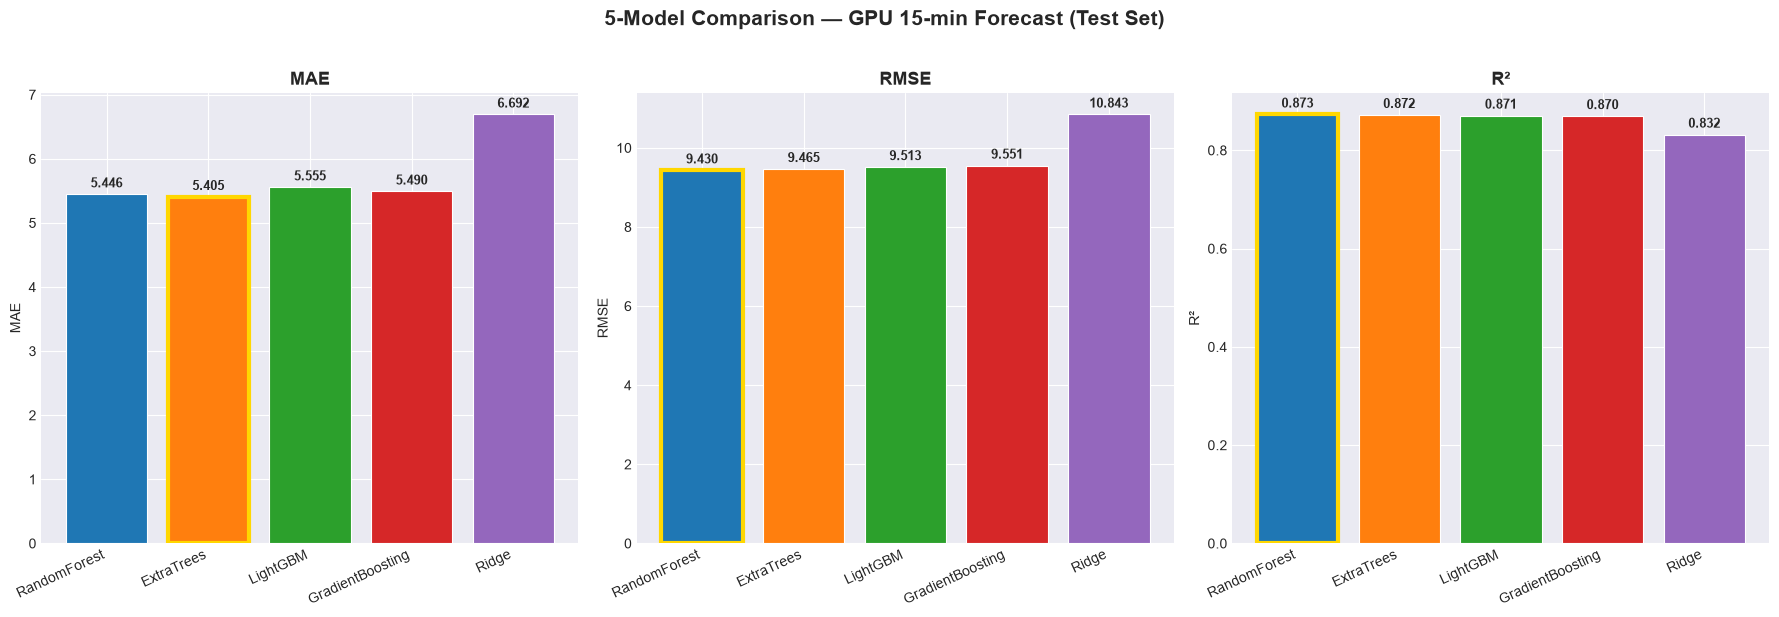

✅ Saved: 09_ml_metric_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("5-Model Comparison — GPU 15-min Forecast (Test Set)",
             fontsize=15, fontweight="bold", y=1.02)

metrics  = ["MAE", "RMSE", "R²"]
colors   = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
models   = results_df.index.tolist()

for ax, metric in zip(axes, metrics):
    vals  = [results[m][metric] for m in models]
    bars  = ax.bar(models, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontweight="bold", fontsize=13)
    ax.set_ylabel(metric)
    ax.set_xticklabels(models, rotation=25, ha="right")

    # Label each bar
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Highlight best bar
    best_idx = vals.index(min(vals)) if metric != "R²" else vals.index(max(vals))
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/09_ml_metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 09_ml_metric_comparison.png")

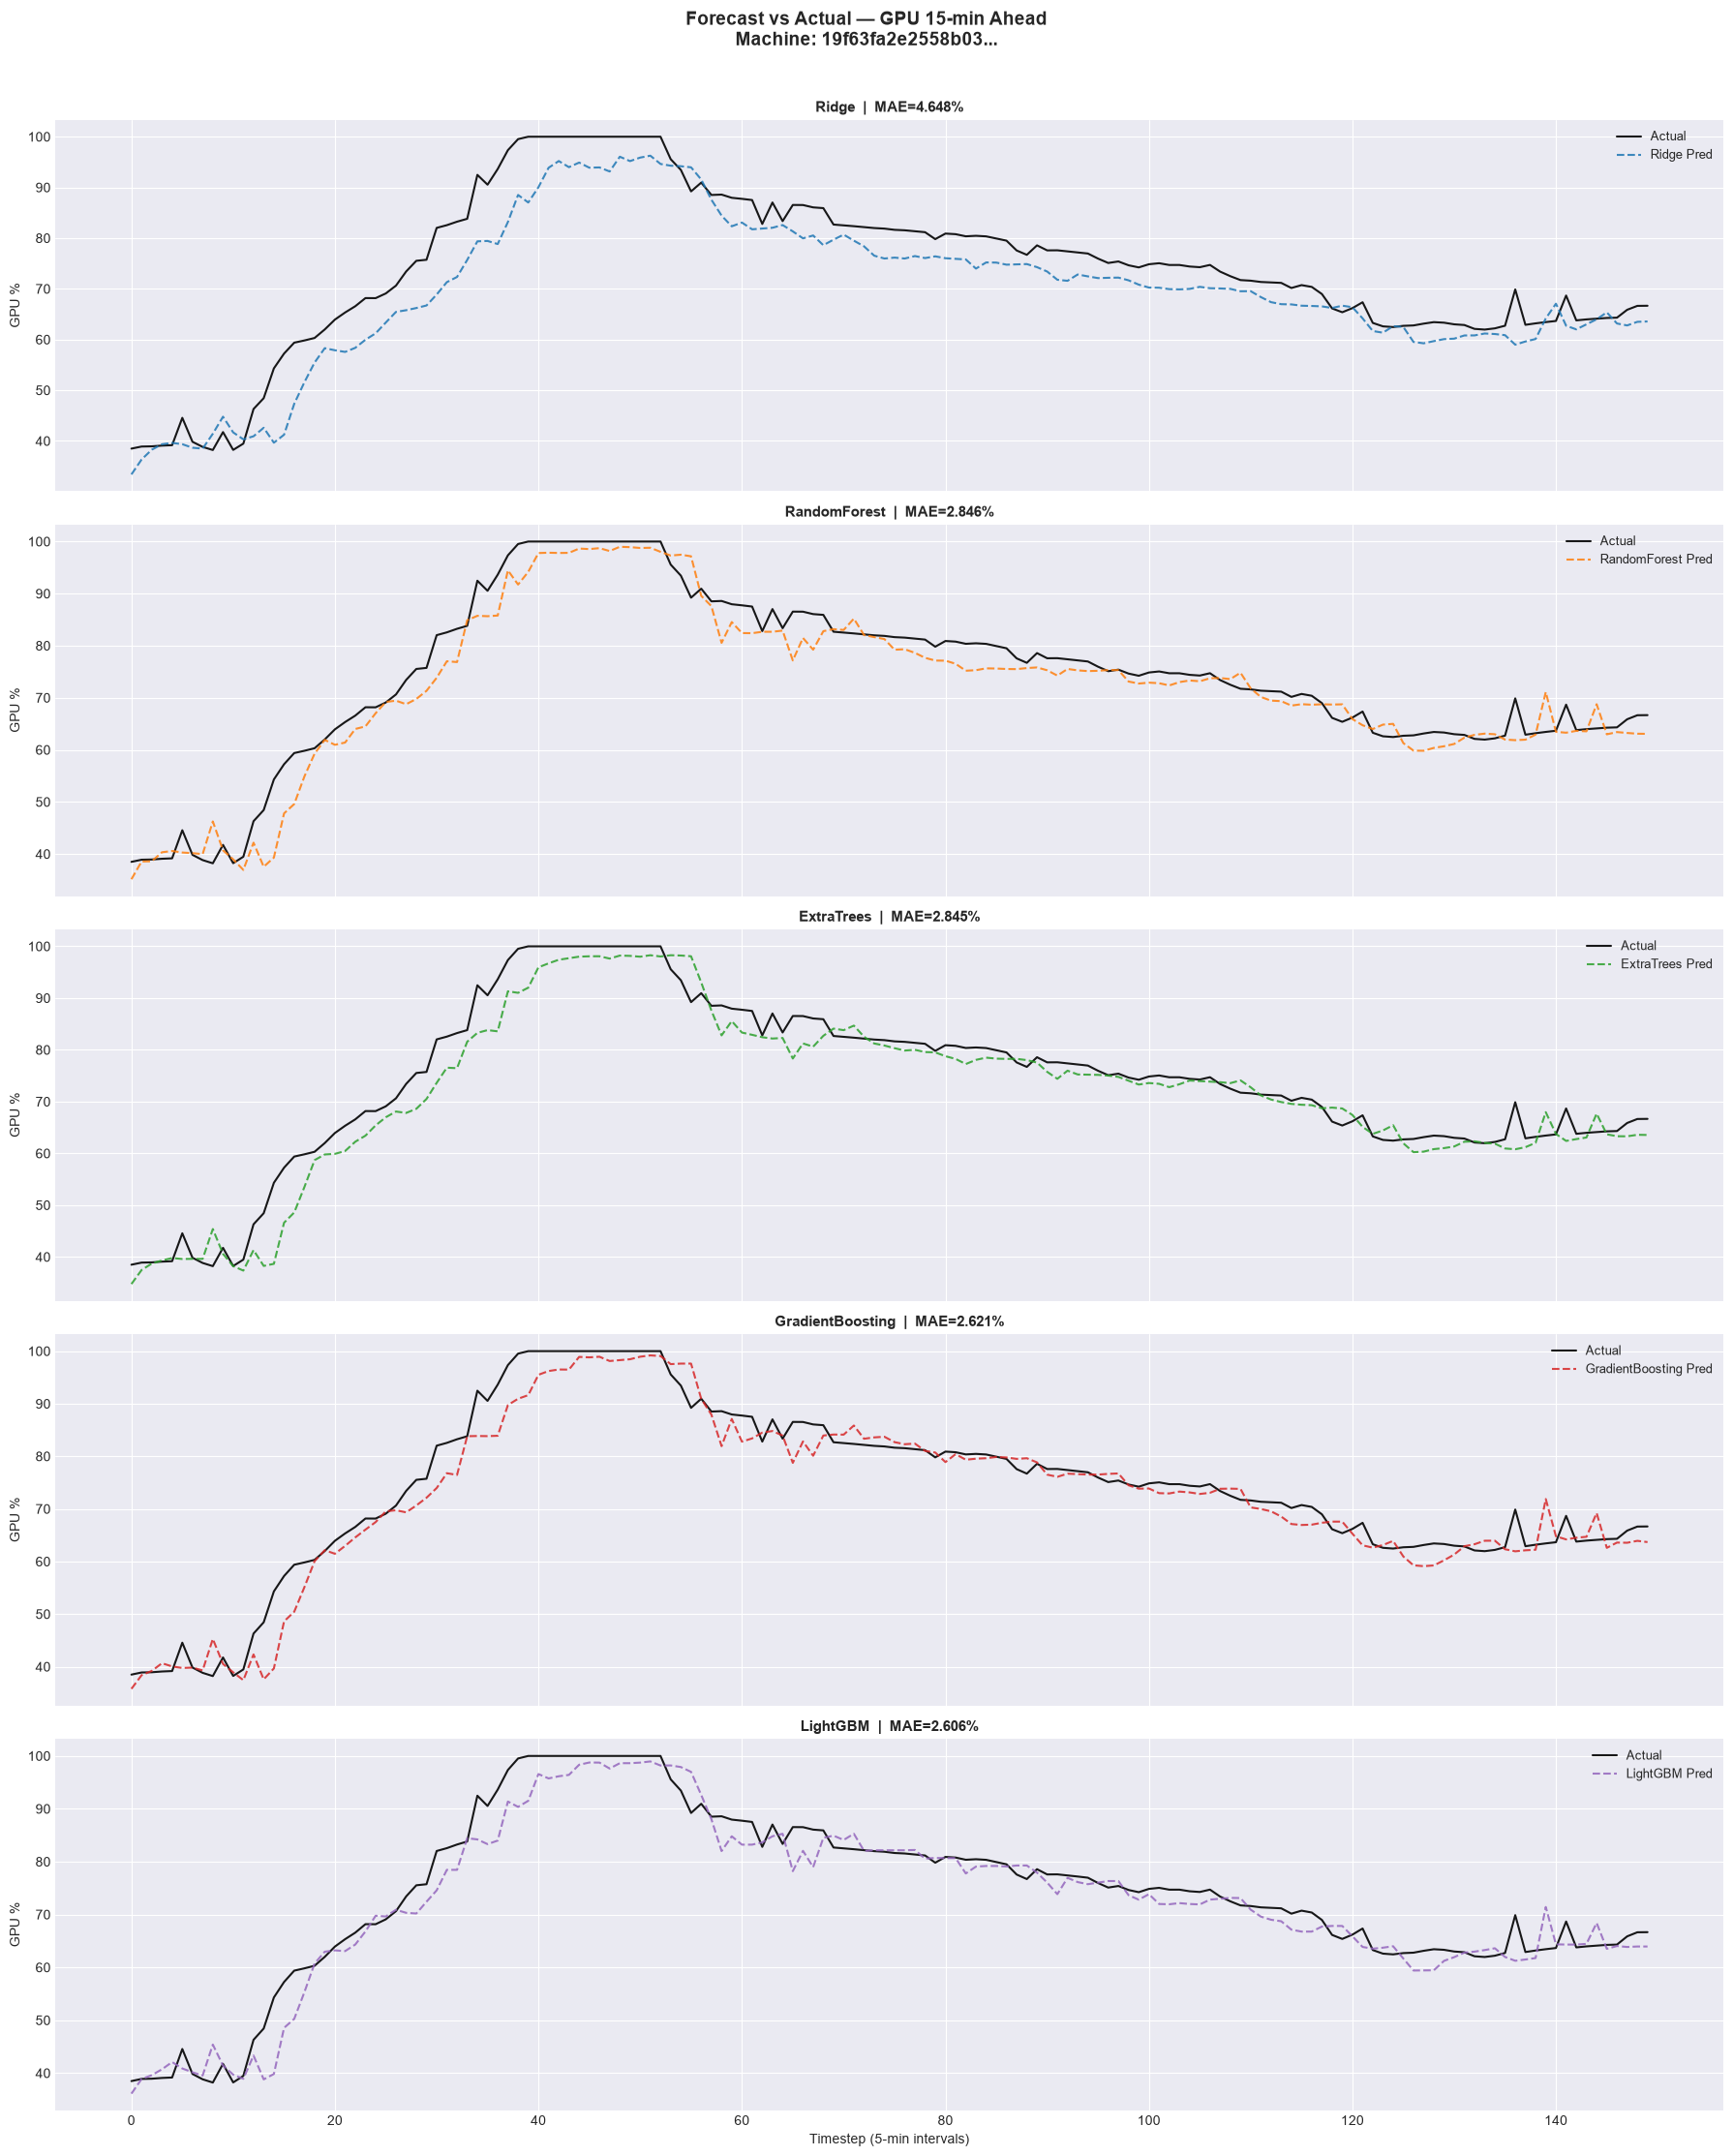

✅ Saved: 10_all_models_forecast.png


In [9]:
# Pick most data-rich machine from test set
sample_machine = test_df["machine"].value_counts().index[0]
plot_df = test_df[test_df["machine"] == sample_machine].sort_values("timestamp").head(150)

fig, axes = plt.subplots(5, 1, figsize=(18, 22), sharex=True)
fig.suptitle(f"Forecast vs Actual — GPU 15-min Ahead\nMachine: {sample_machine[:16]}...",
             fontsize=14, fontweight="bold", y=1.01)

actual = plot_df[PRIMARY_TARGET].values
colors_line = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for ax, (name, color) in zip(axes, zip(MODELS.keys(), colors_line)):
    pred_all = predictions[name]
    # Align predictions back to the plot_df rows
    test_indices = test_df[test_df["machine"] == sample_machine].sort_values("timestamp").head(150).index
    pred_slice = predictions[name][
        [list(test_df.index).index(i) for i in test_indices if i in test_df.index]
    ]

    ax.plot(actual,     color="black",  linewidth=1.5, label="Actual",    alpha=0.9)
    ax.plot(pred_slice, color=color,    linewidth=1.5, label=f"{name} Pred", linestyle="--", alpha=0.85)

    mae_here = mean_absolute_error(actual[:len(pred_slice)], pred_slice)
    ax.set_ylabel("GPU %")
    ax.set_title(f"{name}  |  MAE={mae_here:.3f}%", fontweight="bold", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Timestep (5-min intervals)")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/10_all_models_forecast.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 10_all_models_forecast.png")

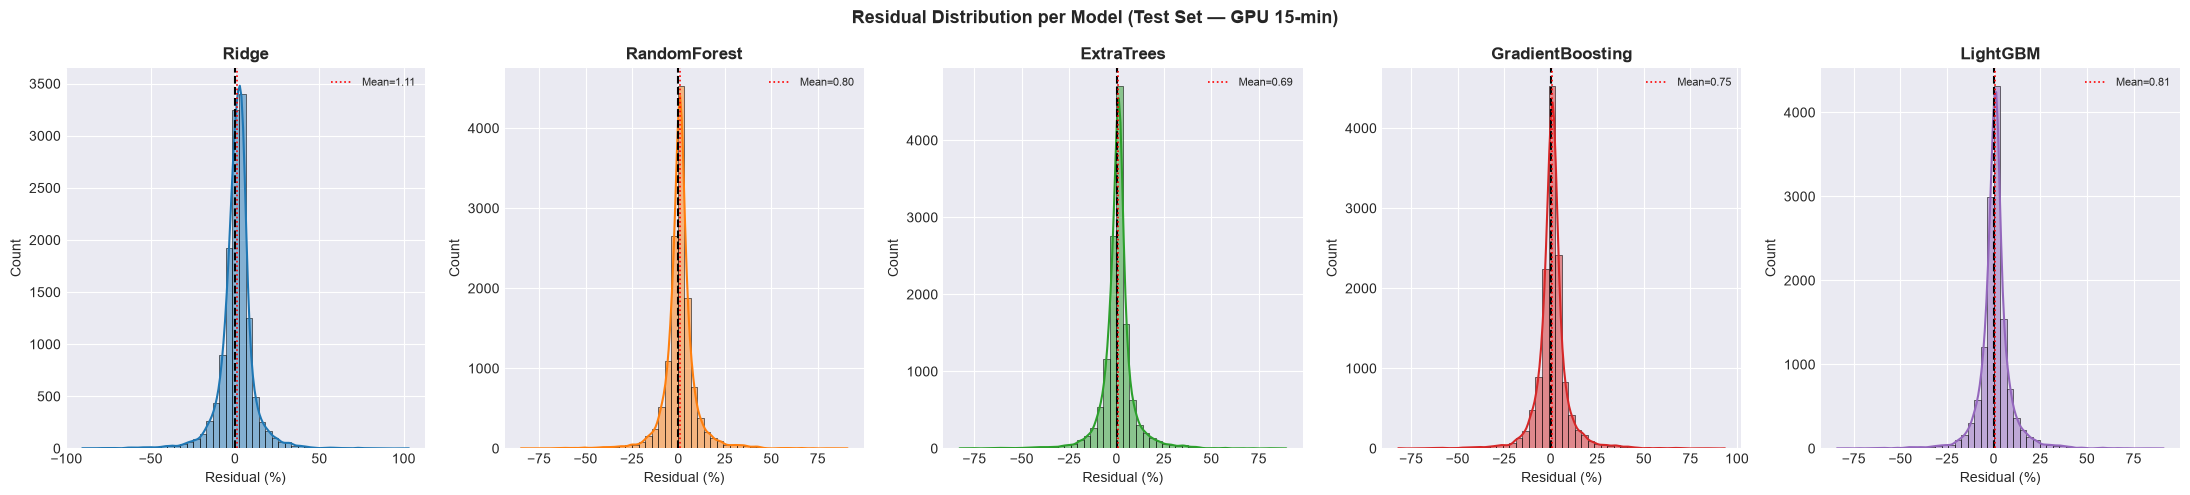

✅ Saved: 11_residual_distributions.png


In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Residual Distribution per Model (Test Set — GPU 15-min)",
             fontsize=13, fontweight="bold")

for ax, (name, color) in zip(axes, zip(MODELS.keys(), colors)):
    residuals = y_test_gpu - predictions[name]
    sns.histplot(residuals, bins=50, ax=ax, color=color, kde=True)
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax.axvline(residuals.mean(), color="red", linewidth=1.2, linestyle=":",
               label=f"Mean={residuals.mean():.2f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Residual (%)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/11_residual_distributions.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 11_residual_distributions.png")

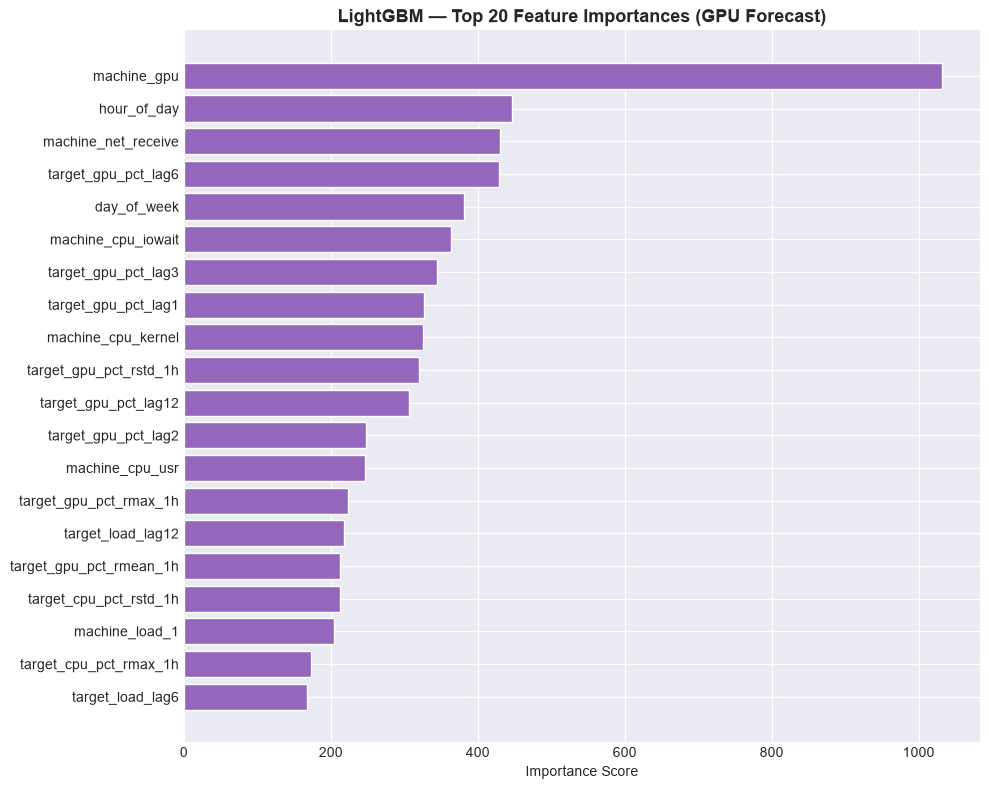

✅ Saved: 12_lgbm_feature_importance.png


In [11]:
import lightgbm as lgb

lgb_model = MODELS["LightGBM"]

fi_df = pd.DataFrame({
    "feature"   : X_COLS,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=True).tail(20)

plt.figure(figsize=(10, 8))
bars = plt.barh(fi_df["feature"], fi_df["importance"], color="#9467bd", edgecolor="white")
plt.title("LightGBM — Top 20 Feature Importances (GPU Forecast)", fontweight="bold", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/12_lgbm_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 12_lgbm_feature_importance.png")

In [12]:
# Now train the BEST model on all 9 targets (3 targets × 3 horizons)
# This gives us the full multi-target multi-horizon baseline

best_model_class = type(MODELS[best_model_name])
all_results = {}

print(f"🏆 Extending best model ({best_model_name}) to all targets & horizons")
print("=" * 60)

for target in TARGET_COLS:
    for horizon in HORIZONS:
        future_col = f"FUTURE_{target}_{horizon}"

        y_tr = train_df[future_col].values
        y_te = test_df[future_col].values

        m = joblib.load(f"{MODEL_DIR}/ml_{best_model_name.lower()}_gpu.pkl")
        # Re-instantiate fresh model for each target
        import copy
        m = copy.deepcopy(MODELS[best_model_name])

        X_tr = X_train_s if best_model_name == "Ridge" else X_train
        X_te = X_test_s  if best_model_name == "Ridge" else X_test

        if best_model_name == "LightGBM":
            X_vl = X_val_s if best_model_name == "Ridge" else X_val
            y_vl = val_df[future_col].values
            m.fit(X_tr, y_tr,
                  eval_set=[(X_vl, y_vl)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(period=-1)])
        else:
            m.fit(X_tr, y_tr)

        y_pred = m.predict(X_te)
        mae    = mean_absolute_error(y_te, y_pred)
        rmse   = root_mean_squared_error(y_te, y_pred)
        r2     = r2_score(y_te, y_pred)

        key = f"{target} | {horizon}"
        all_results[key] = {"MAE": round(mae,3), "RMSE": round(rmse,3), "R²": round(r2,4)}
        joblib.dump(m, f"{MODEL_DIR}/ml_{best_model_name.lower()}_{target}_{horizon}.pkl")
        print(f"  {key:<40}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")

print("\n✅ All 9 models trained and saved")

🏆 Extending best model (RandomForest) to all targets & horizons
  target_gpu_pct | 5min                     MAE=2.694  RMSE=5.694  R²=0.9537
  target_gpu_pct | 15min                    MAE=5.446  RMSE=9.430  R²=0.8729
  target_gpu_pct | 30min                    MAE=8.774  RMSE=13.176  R²=0.7542
  target_cpu_pct | 5min                     MAE=0.792  RMSE=1.551  R²=0.9604
  target_cpu_pct | 15min                    MAE=1.549  RMSE=2.571  R²=0.8917
  target_cpu_pct | 30min                    MAE=2.518  RMSE=3.797  R²=0.7665
  target_load | 5min                        MAE=1.292  RMSE=3.426  R²=0.9551
  target_load | 15min                       MAE=2.444  RMSE=5.226  R²=0.8953
  target_load | 30min                       MAE=4.041  RMSE=8.016  R²=0.7528

✅ All 9 models trained and saved


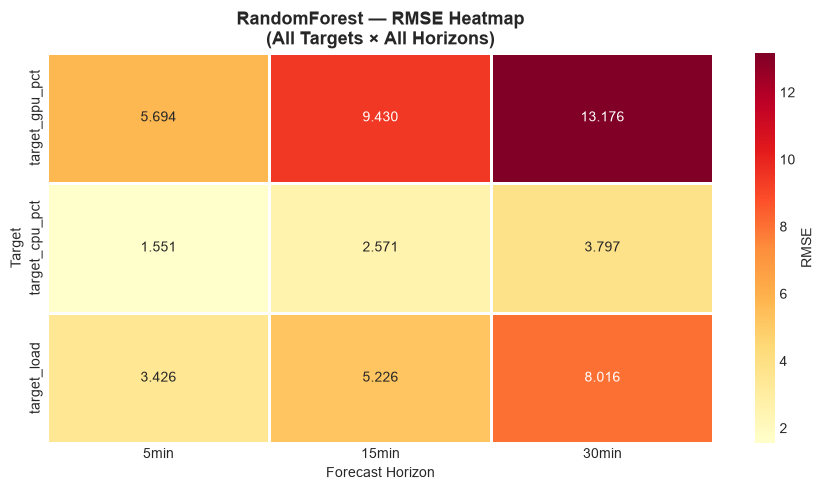

✅ Saved: 13_rmse_heatmap_all_targets.png


In [13]:
# Heatmap of RMSE across all 3 targets × 3 horizons
# Shows how error grows as forecast horizon increases

rmse_matrix = pd.DataFrame(
    index=TARGET_COLS,
    columns=list(HORIZONS.keys()),
    dtype=float
)

for target in TARGET_COLS:
    for horizon in HORIZONS:
        rmse_matrix.loc[target, horizon] = all_results[f"{target} | {horizon}"]["RMSE"]

plt.figure(figsize=(9, 5))
sns.heatmap(
    rmse_matrix.astype(float),
    annot=True, fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.8,
    cbar_kws={"label": "RMSE"}
)
plt.title(f"{best_model_name} — RMSE Heatmap\n(All Targets × All Horizons)",
          fontweight="bold", fontsize=13)
plt.xlabel("Forecast Horizon")
plt.ylabel("Target")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/13_rmse_heatmap_all_targets.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 13_rmse_heatmap_all_targets.png")

In [14]:
print("=" * 60)
print("  NOTEBOOK 03 COMPLETE")
print("=" * 60)
print(f"  Models trained     : 5  (Ridge, RF, ExtraTrees, GB, LightGBM)")
print(f"  Primary target     : GPU 15-min ahead")
print(f"  Best model         : {best_model_name}")
print(f"  Best RMSE          : {results_df.loc[best_model_name, 'RMSE']:.4f}%")
print(f"  Best R²            : {results_df.loc[best_model_name, 'R²']:.4f}")
print(f"  Full coverage      : 3 targets × 3 horizons = 9 models saved")
print(f"  Models saved to    : {MODEL_DIR}")
print(f"  Charts saved       : 5 PNGs → {REPORT_DIR}")
print("=" * 60)
print("\n✅ Ready for → 04_lstm_deep_learning.ipynb")

  NOTEBOOK 03 COMPLETE
  Models trained     : 5  (Ridge, RF, ExtraTrees, GB, LightGBM)
  Primary target     : GPU 15-min ahead
  Best model         : RandomForest
  Best RMSE          : 9.4304%
  Best R²            : 0.8729
  Full coverage      : 3 targets × 3 horizons = 9 models saved
  Models saved to    : ../outputs/models
  Charts saved       : 5 PNGs → ../outputs/reports

✅ Ready for → 04_lstm_deep_learning.ipynb
